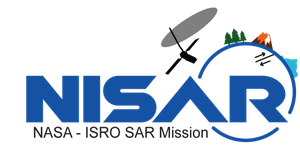

# NISAR Sea Ice Motion
**NASA ISRO Synthetic Aperture Radar (NISAR) Mission**

**Authors:** Talib Oliver-Cabrera, Adam Vaccaro, Denis Demchev, Ben Holt  
**Affiliation:** NASA Jet Propulsion Laboratory, California Institute of Technology  
**Date:** 2026-03-18  
**Last updated:** March 2026  


In [ ]:
# Library imports
import os
import core
from pathlib import Path

import asf_search as asf
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer

# Local modules
import combined.run_from_pair as run_from_pair
import preprocessing.geocoding as geocoding
from preprocessing.preprocessor import safe_run_grd_warp as reproject
from postprocessing.outlier_filter import filter_sea_ice_motion

# helper functions
from utils.aoi import check_polygon_validity, kml_to_wkt, load_aoi_polygon, polygon_hemisphere
from utils.search import find_overlapping_pairs, select_scenes_overlapping_a_station
from utils.download import get_earthdata_credentials, download_asf_pair_authenticated, unzip_file, get_hh_tiff
from utils.viz import plot_granule_pair, interactive_granule_pair, interactive_overlap_map, interactive_vector_field
from utils.raster import load_data, get_geocorner, combine_geocor, nisar_to_geotiff


### Setup work paths

In [ ]:
# Define work directory and paths
work_dir = Path('./sea_ice_motion_run')
work_dir.mkdir(parents=True, exist_ok=True)

# Path to grids 
grid_dir = Path('./motion_grids')

# input SAR product
sar_mission = 'nisar' # 'sentinel-1' or 'nisar'

# indicate if the images to be used are already projected to polar stereographic (Sentinel-1 only)
projected = False # True if image is projected already  

### Define AOI polygon and observation date time
Define a AOI polygon by giving coordinates or by providing a kml file.

In [ ]:
# Provide a KML file path or a WKT polygon string e.g."POLYGON((-90 82,0 82,42 84,-132 84,-90 82))"

#aoi_polygon = "path/to/file/weddell_query.kml" 

aoi_polygon = "POLYGON((-61 -72, -51 -72, -51 -67, -61 -67, -61 -72))"
start_date = '2025-10-01'
end_date = '2025-11-04' 

### Query SAR data over a region of interest 

In [ ]:
wkts_poly = load_aoi_polygon(aoi_polygon)
check_polygon_validity(wkts_poly)
wkts_poly

In [ ]:
# Search for available data over the chosen AOI and time range.
hemisphere, epsg_code = polygon_hemisphere(wkts_poly, return_both=False)

if sar_mission == 'sentinel-1':
    print(f"Searching for Sentinel-1 GRD-MD data in {hemisphere} hemisphere")
    results = asf.geo_search(platform=[asf.PLATFORM.SENTINEL1], 
                            intersectsWith=wkts_poly,
                            processingLevel=["GRD_MD"],
                            beamMode=[asf.BEAMMODE.EW], 
                            start=start_date, 
                            end=end_date)

if sar_mission == 'nisar':
    print(f"Searching for NISAR GCOV data in {hemisphere} hemisphere")
    results = asf.geo_search(
        platform=[asf.PLATFORM.NISAR],
        intersectsWith=wkts_poly,
        processingLevel=[asf.PRODUCT_TYPE.GCOV],
        start=start_date,
        end=end_date
    ) 

In [ ]:
# Inspect search results
gdf_results = gpd.GeoDataFrame.from_features(results.geojson()['features'])
print(len(gdf_results))
gdf_results.head()

### If there is a known Buoy location of interest: 
Use the station location to find the pairs that overlap it. Uncomment cell below

In [ ]:
# lon, lat = -51.7548, -68.438   # Example coordinate in Antarctica

# gdf_results = select_scenes_overlapping_a_station(gdf_results, lon, lat)
# print(len(gdf_results))
# gdf_results

### Create image pairs
Image pairs are create usign a 30% overlap and a Max time delta of 3 days. 

In [ ]:
pairs_df = find_overlapping_pairs(gdf_results)
print(len(pairs_df))
pairs_df.head()

### Visualize available pairs

In [ ]:
m = interactive_overlap_map(gdf_results)
m

### Select a SAR pair to generate sea ice motion vectors

In [ ]:
# Select a pair to run through the sea ice motion vector estimation workflow.
index_to_use = 2 # Sentinel-1 example pair
# index_to_use = 5 # NISAR example pair

# Extact date of the selected pair
row = pairs_df.iloc[index_to_use] 
fmt = "%Y%m%dT%H%M%S" # Format: YYYYMMDDThhmmss
pair_datetime = f"{row['startTime1'].strftime(fmt)}_{row['startTime2'].strftime(fmt)}"

print('Selected pair index:', index_to_use)
print('Selected pair date:', pair_datetime)

In [ ]:
plot_granule_pair(pairs_df, gdf_results, pair_index=index_to_use)

In [ ]:
# Ensure CRS before plotting.
if gdf_results.crs is None:
    gdf_results = gdf_results.set_crs("EPSG:4326")

m = interactive_granule_pair(pairs_df, gdf_results, pair_index=index_to_use)
m

### Download data for selected pair

In [ ]:
# output dir
out_dir = work_dir / f"{sar_mission}_seaice_motion_{pair_datetime}"
out_dir.mkdir(parents=True, exist_ok=True)

gran1_path, gran2_path = download_asf_pair_authenticated(
    pairs_df, gdf_results, pair_index=index_to_use, output_dir=out_dir
)

print(gran1_path)
print(gran2_path)

### Prepare SAR images

In [ ]:
if sar_mission == 'nisar':
    # Convert NISAR GCOV to GeoTIFF
    IMAGE_PAIR1 = nisar_to_geotiff(gran1_path, output_dir=out_dir)
    IMAGE_PAIR2 = nisar_to_geotiff(gran2_path, output_dir=out_dir)

if sar_mission == 'sentinel-1':
    # unzip paths
    extracted_p1 = unzip_file(gran1_path)
    print("Files extracted to:", extracted_p1)

    extracted_p2 = unzip_file(gran2_path)
    print("Files extracted to:", extracted_p2)

    IMAGE_PAIR1 = get_hh_tiff(extracted_p1)
    print("IMAGE_PAIR1:", IMAGE_PAIR1)
    IMAGE_PAIR2 = get_hh_tiff(extracted_p2)
    print("IMAGE_PAIR2:", IMAGE_PAIR2)

In [ ]:
CORE_OUTPUT_PATH = out_dir / 'rgpspy_run'
RESULTS_OUTPUT_PATH = out_dir / 'rgpspy_run/results'
gridfile = grid_dir / f'5km_{str(epsg_code)}.shp'

if hemisphere == 'South':
    REGION = geocoding.ANTARCTIC
elif hemisphere == 'North':
    REGION = geocoding.ARCTIC
    
TARGET_TIMEFORMAT = '%y%m%d%H%M%S'
PARAMS = os.path.join(os.path.dirname(core.__file__), 'src', 'inc', 'sentinel_rsparm_p13.inp')

In [ ]:
if sar_mission == 'sentinel-1' and not projected:
    IMAGE_PAIR1_REPROJ = IMAGE_PAIR1.with_name(IMAGE_PAIR1.stem + "_reproj.tif")
    print(f"Reprojecting {IMAGE_PAIR1} to {IMAGE_PAIR1_REPROJ}")
    reproject(IMAGE_PAIR1, IMAGE_PAIR1_REPROJ, epsg_code)
    IMAGE_PAIR2_REPROJ = IMAGE_PAIR2.with_name(IMAGE_PAIR2.stem + "_reproj.tif")
    print(f"Reprojecting {IMAGE_PAIR2} to {IMAGE_PAIR2_REPROJ}")
    reproject(IMAGE_PAIR2, IMAGE_PAIR2_REPROJ, epsg_code)
else:
    print("Images are already projected, skipping reprojection step.")
    IMAGE_PAIR1_REPROJ = IMAGE_PAIR1
    IMAGE_PAIR2_REPROJ = IMAGE_PAIR2

In [ ]:
# output name for the motion vector product
output_name = f"{sar_mission}_seaice_motion_{pair_datetime}"

### Run Sea Ice motion calculation

In [ ]:
# Run the core processing
run_from_pair.setup_and_run_core(
	CORE_OUTPUT_PATH, 
	IMAGE_PAIR1_REPROJ, 
	IMAGE_PAIR2_REPROJ, 
	gridfile, 
	output_name, 
	PARAMS
)

In [ ]:
# Read in the resulting vector field
vector_field_path = RESULTS_OUTPUT_PATH / f'{output_name}.shp'

# Clean outliers
# filter vectors, this example will create a new shapefile with '_filtered' suffix in the same directory
filtered_shp_path = filter_sea_ice_motion(vector_field_path)

# read in the filtered vector field
vector_field_filtered = gpd.read_file(filtered_shp_path)
vector_field_filtered = vector_field_filtered.set_geometry('geometry')

In [ ]:
x1_f, y1_f, x2_f, y2_f = np.array(vector_field_filtered.x.to_list()), np.array(vector_field_filtered.y.to_list()), np.array(vector_field_filtered.x2.to_list()), np.array(vector_field_filtered.y2.to_list())
# Calculate displacement for the filtered set
uu_f, vv_f = x2_f - x1_f, y2_f - y1_f

### Overview of sea ice motion vectors 

In [ ]:
sar1_path = IMAGE_PAIR1_REPROJ
sar2_path = IMAGE_PAIR2_REPROJ

# Read data
sar1, sar1_tran = load_data(sar1_path)
sar1_geocor = get_geocorner(sar1, sar1_tran)
sar2, sar2_tran = load_data(sar2_path)
sar2_geocor = get_geocorner(sar2, sar2_tran)
# Extract full coordinate coverage
full_geo_extent = combine_geocor(sar1_geocor, sar2_geocor)

In [ ]:
# Plot things
if sar_mission == 'sentinel-1':
    vmin, vmax = 0, 900
elif sar_mission == 'nisar':
    vmin, vmax = -30, -15
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
cax = ax.imshow([[0, 0], [0, 0]], extent=full_geo_extent, cmap='Paired', origin='lower')
cax = ax.imshow(np.ma.masked_where(sar1==0, sar1), extent=sar1_geocor, vmin=vmin, vmax=vmax, cmap = 'gray', interpolation='nearest')
cax = ax.imshow(np.ma.masked_where(sar2==0, sar2), extent=sar2_geocor, vmin=vmin, vmax=vmax, cmap = 'gray', interpolation='nearest')
cax = ax.quiver(x1_f, y1_f, uu_f, vv_f, color='red', label='S1 motion field')
ax.set_xlim(full_geo_extent[0], full_geo_extent[1])
ax.set_ylim(full_geo_extent[2], full_geo_extent[3])
ax.set_title('Sea ice motion field', fontweight='bold')
plt.grid(linestyle='--')
plt.show()

In [ ]:
interactive_vector_field(vector_field_filtered)